# Toy Car Audio Visualization + Preprocessing

**Purpose:** This notebook presents a complete pipeline for the toy audio (.wav) visualization, analysis, and converting into .npy for futher use without having to preprocess repeatedly.

## 1. Imports

In [ ]:
import os
import glob
import numpy as np

from helpers.helper_audio_data import (
    build_multichannel_tensor, 
    plot_cropped_audio, 
    plot_cnt_segmented_audio, 
    extract_and_save_cnt_segments, 
    group_wavs
)

from helpers.helper_npy_data import (
    split_cnt_to_segments_and_save, 
)

## 2. Paths and configurations

In [3]:
# Paths
DATA_BASE_PATH = "F:ToyCar"
CNT_ROOT = os.path.join(DATA_BASE_PATH, "npy", "CNT")
IND_ROOT = os.path.join(DATA_BASE_PATH, "npy", "IND")
CNT_SEG_ROOT = os.path.join(DATA_BASE_PATH, "npy", "CNT_SEG")


In [4]:
# Configs

CASES = ['case1', 'case2', 'case3', 'case4']
CHANNELS = ['1', '2', '3', '4']
SEED = 42

## 3. Data Processing

This section builds normal and anomalous datasets from raw wav files.

Design notes:
- A fixed crop window keeps temporal coverage consistent across samples.
- Each sample must contain all four channels.
- Core data logic lives in `helpers/helper_audio_data.py` for reuse across notebooks.

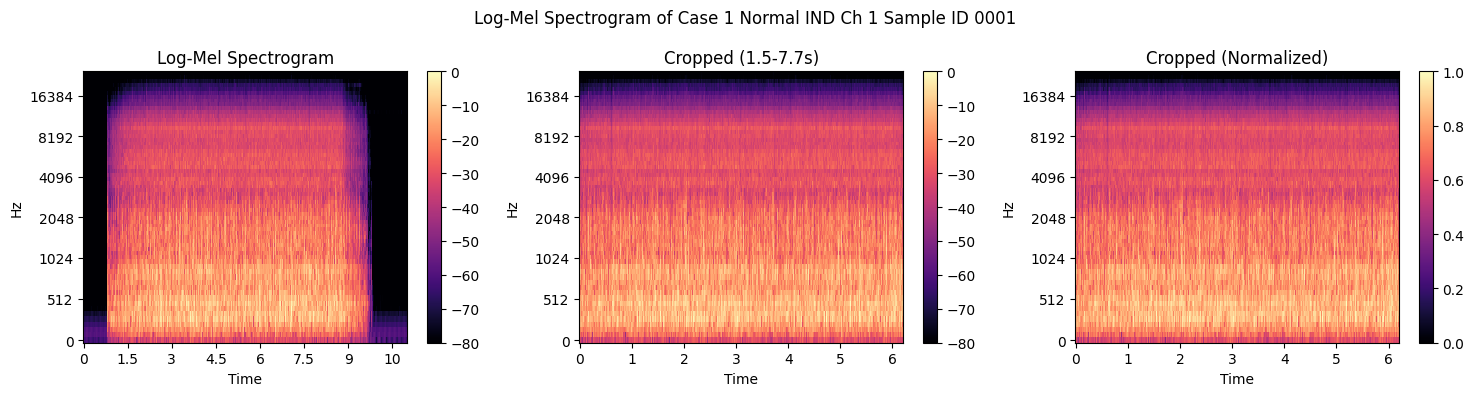

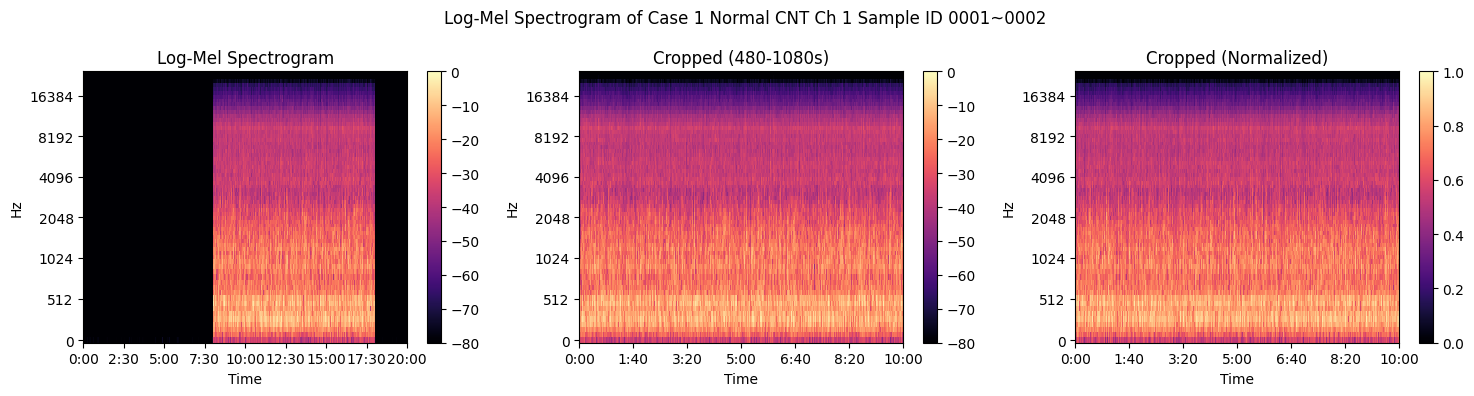

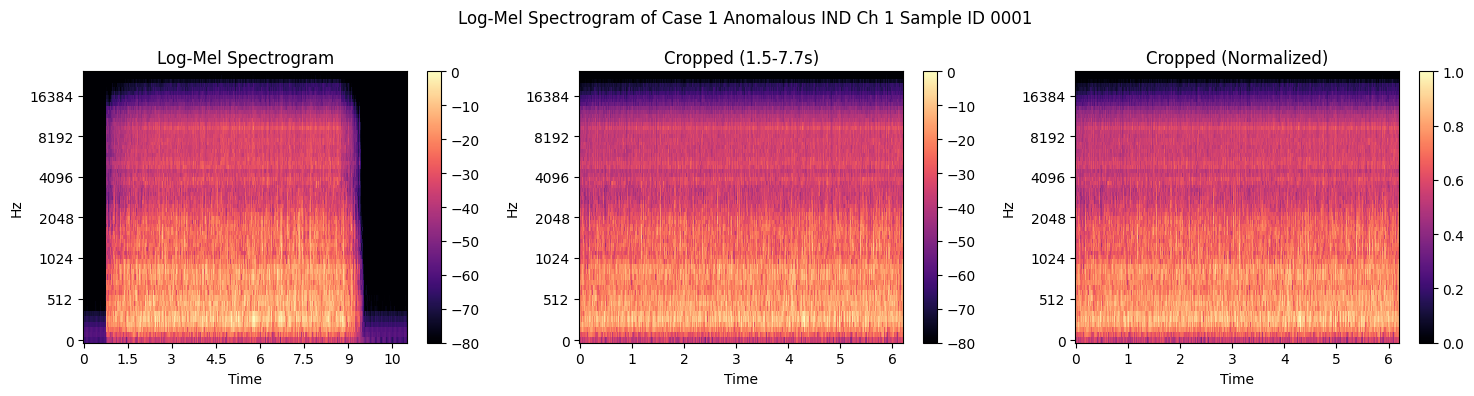

In [ ]:
# The figures below show the spectrograms of a single Normal IND, Normal CNT, and Anomalous IND audio sample.

# The leftmost plot illustrates that all cases contain silent segments, which should be removed.
# The middle plot shows the spectrogram after cropping out these silent regions.
# The rightmost plot presents the cropped spectrogram after min–max normalization.

# After this preprocessing step, the .npy data corresponding to the rightmost plot is stored for further use.

plot_cropped_audio(
    [
        f"{DATA_BASE_PATH}/case1/NormalSound_IND/1100010001_ToyCar_case1_normal_IND_ch1_0001.wav"
    ], 
    "Log-Mel Spectrogram of Case 1 Normal IND Ch 1 Sample ID 0001", 1.5, 7.7
)

plot_cropped_audio(
    [
        f"{DATA_BASE_PATH}/case1/NormalSound_CNT/1100110001_ToyCar_case1_normal_CNT_ch1_0001.wav", 
        f"{DATA_BASE_PATH}/case1/NormalSound_CNT/1100110002_ToyCar_case1_normal_CNT_ch1_0002.wav"
    ], 
    "Log-Mel Spectrogram of Case 1 Normal CNT Ch 1 Sample ID 0001~0002", 8*60, 18*60
)

plot_cropped_audio(
    [
        f"{DATA_BASE_PATH}/case1/AnomalousSound_IND/1101010001_ToyCar_case1_ab01_IND_ch1_0001.wav"
    ], 
    "Log-Mel Spectrogram of Case 1 Anomalous IND Ch 1 Sample ID 0001", 1.5, 7.7)

Cropping, converting to log-mel spectrogram and saving as .npy for normal IND and anomalous IND data:

In [21]:
# For Normal IND and Anomalous IND:
# first group normal and anomalous IND data into group of 4 channels, according to their case and sample_id 

grouped_normal_samples = group_wavs(
    data_base_path=DATA_BASE_PATH,
    cases=CASES,
    folder_name="NormalSound_IND",
    channels=CHANNELS,
    anomaly_mode=False
)

grouped_anom_samples = group_wavs( 
    data_base_path=DATA_BASE_PATH,
    cases=CASES,
    folder_name="AnomalousSound_IND",
    channels=CHANNELS,
    anomaly_mode=True
) # [((case, sample_id), {ch: path})]

print("Example: ")
display(grouped_normal_samples[0])

Example: 


(('case1', '0945'),
 {'1': 'F:ToyCar\\case1\\NormalSound_IND\\1100010945_ToyCar_case1_normal_IND_ch1_0945.wav',
  '2': 'F:ToyCar\\case1\\NormalSound_IND\\1100020945_ToyCar_case1_normal_IND_ch2_0945.wav',
  '3': 'F:ToyCar\\case1\\NormalSound_IND\\1100030945_ToyCar_case1_normal_IND_ch3_0945.wav',
  '4': 'F:ToyCar\\case1\\NormalSound_IND\\1100040945_ToyCar_case1_normal_IND_ch4_0945.wav'})

In [ ]:
CROP_START_SEC = 1.5
CROP_END_SEC = 7.7

for i, ((case, sample_id), channel_map) in enumerate(grouped_normal_samples):
    save_folder = f"{DATA_BASE_PATH}/npy/IND/{case}/normal"
    os.makedirs(save_folder, exist_ok=True)

    # Build cropped 4-channel log-mel tensor
    x = build_multichannel_tensor(
        channel_to_path=channel_map,
        channels=CHANNELS,
        start_sec=CROP_START_SEC,
        end_sec=CROP_END_SEC,
    )  # shape: [C, Mel, T]

    # Save
    fname = os.path.join(save_folder, f"{sample_id}.npy")
    np.save(fname, x.numpy())

    print(f"[SAVED] {fname} shape={x.shape}")

[SAVED] F:ToyCar/npy/IND/case1/normal\0945.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0001.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0316.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0002.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0317.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0003.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0318.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0004.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0319.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0005.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/normal\0320.npy shape=torch.Size([4, 64, 582])


In [ ]:
for i, ((case, sample_id), channel_map) in enumerate(grouped_anom_samples):
    save_folder = f"{DATA_BASE_PATH}/npy/IND/{case}/anomaly"
    os.makedirs(save_folder, exist_ok=True)

    # Build cropped multichannel tensor
    x = build_multichannel_tensor(
        channel_to_path=channel_map,
        channels=CHANNELS,
        start_sec=CROP_START_SEC,
        end_sec=CROP_END_SEC,
    )  # shape: [C, Mel, T]

    # Save
    fname = os.path.join(save_folder, f"{sample_id}.npy")
    np.save(fname, x.numpy())

    print(f"[SAVED] {fname} shape={x.shape}")

[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab18_0001.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab01_0001.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab18_0002.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab01_0002.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab18_0005.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab18_0003.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab01_0003.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab01_0004.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab01_0005.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab18_0004.npy shape=torch.Size([4, 64, 582])
[SAVED] F:ToyCar/npy/IND/case1/anomaly\ab19_0001.npy shape=torch.Size([4, 64, 582])


Cropping, converting to log-mel spectrogram and saving as .npy for normal CNT data:

Total duration: 1800.00s
Segment: 480.37s -> 1081.78s | Duration: 601.41s
Segment: 1680.44s -> 1800.00s | Duration: 119.56s
Kept 2 segments


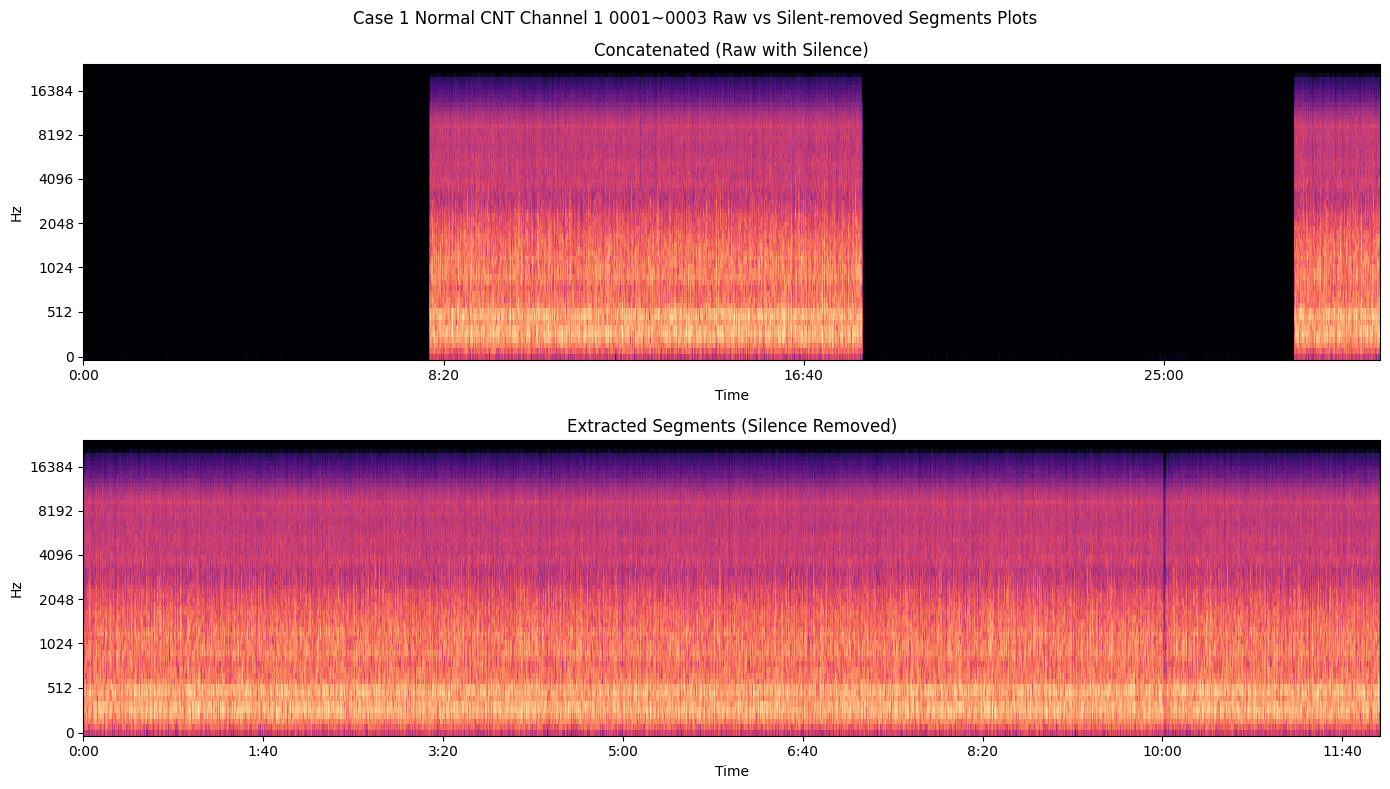

In [ ]:
# For Normal CNT:
# we need to remove the silent segments.
# the silent and non-silent segments have fixed lengths. 
# Therefore, non-silent segments can be extracted using a simple loop and stored as .npy files.

plot_cnt_segmented_audio([
    f"{DATA_BASE_PATH}/case1/NormalSound_CNT/1100110001_ToyCar_case1_normal_CNT_ch1_0001.wav",
    f"{DATA_BASE_PATH}/case1/NormalSound_CNT/1100110002_ToyCar_case1_normal_CNT_ch1_0002.wav", 
    f"{DATA_BASE_PATH}/case1/NormalSound_CNT/1100110003_ToyCar_case1_normal_CNT_ch1_0003.wav", 
    ], 
"Case 1 Normal CNT Channel 1 0001~0003 Raw vs Silent-removed Segments Plots")

Start offset: 1200.42s


C:\Users\ongxu\AppData\Local\Temp\ipykernel_33228\2883498708.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


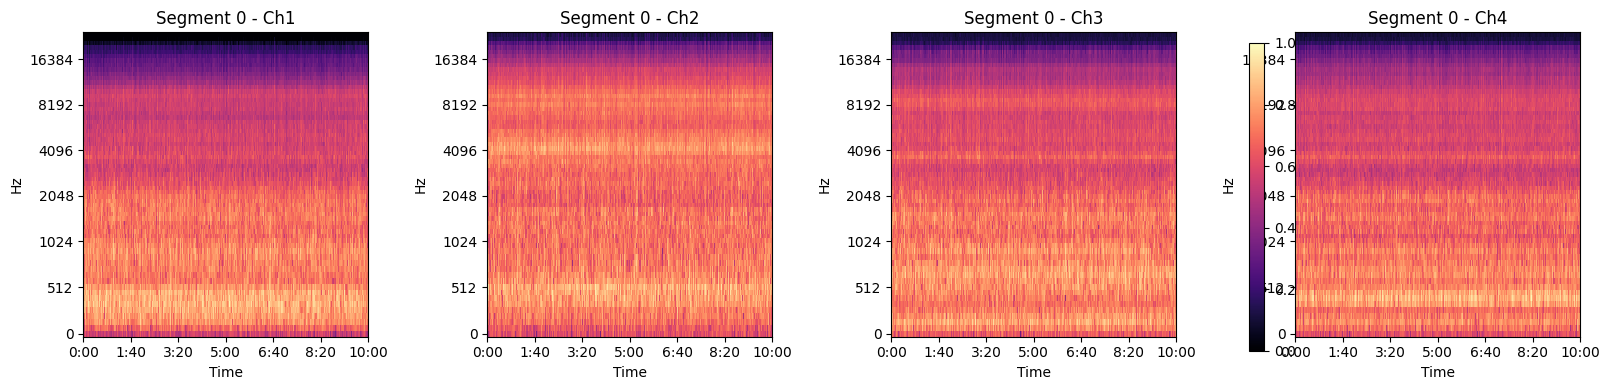

[SEGMENT 0] at 1200.42s


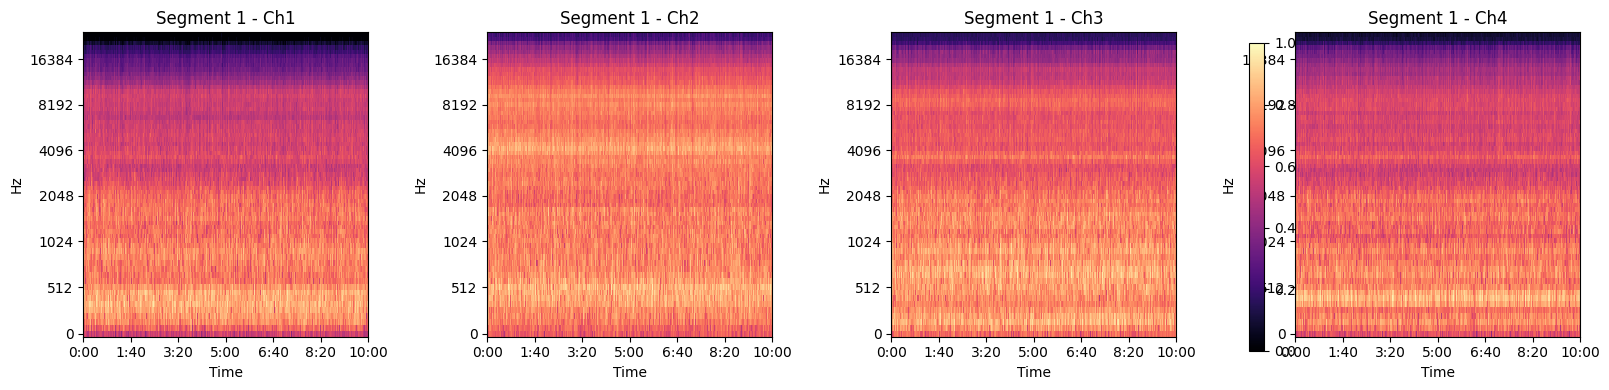

[SEGMENT 1] at 3000.42s


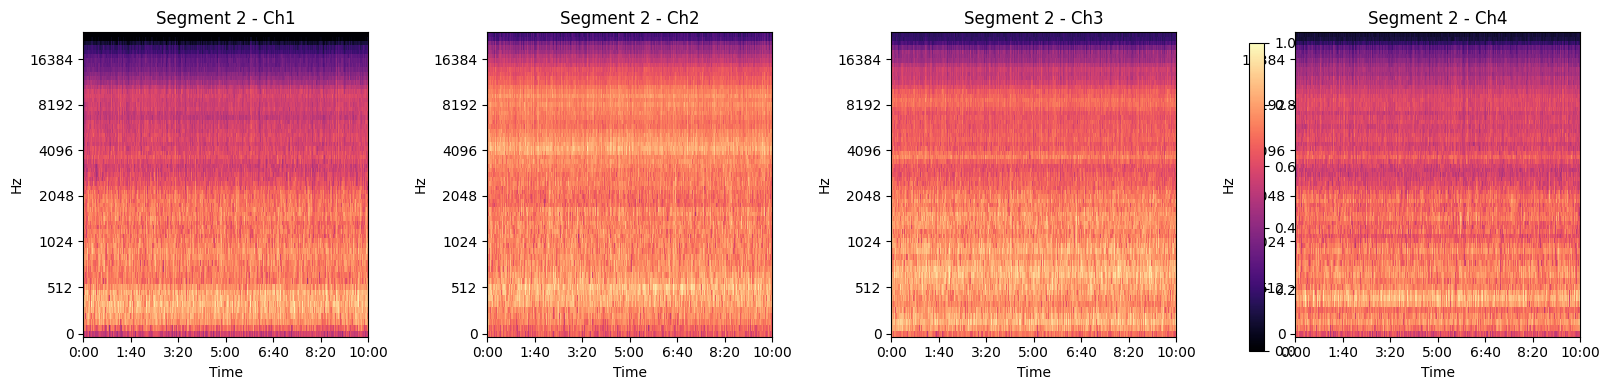

[SEGMENT 2] at 4800.42s


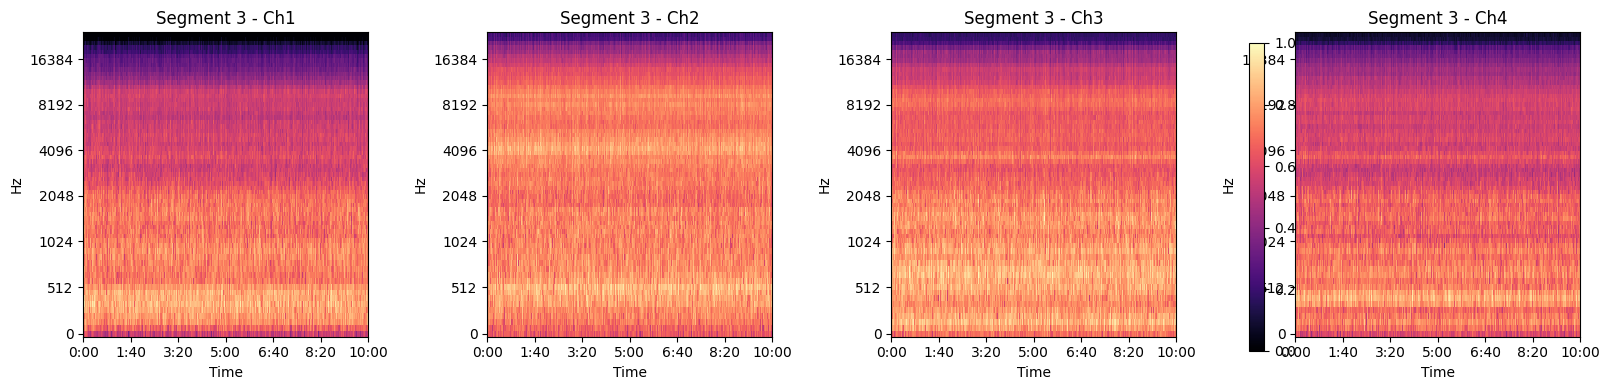

[SEGMENT 3] at 6600.42s


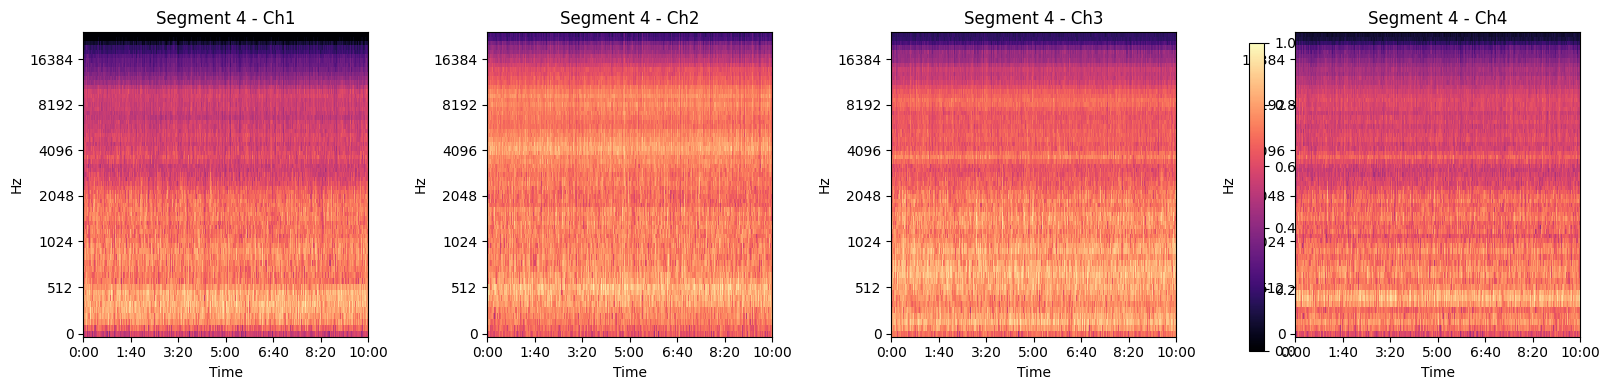

[SEGMENT 4] at 8400.42s


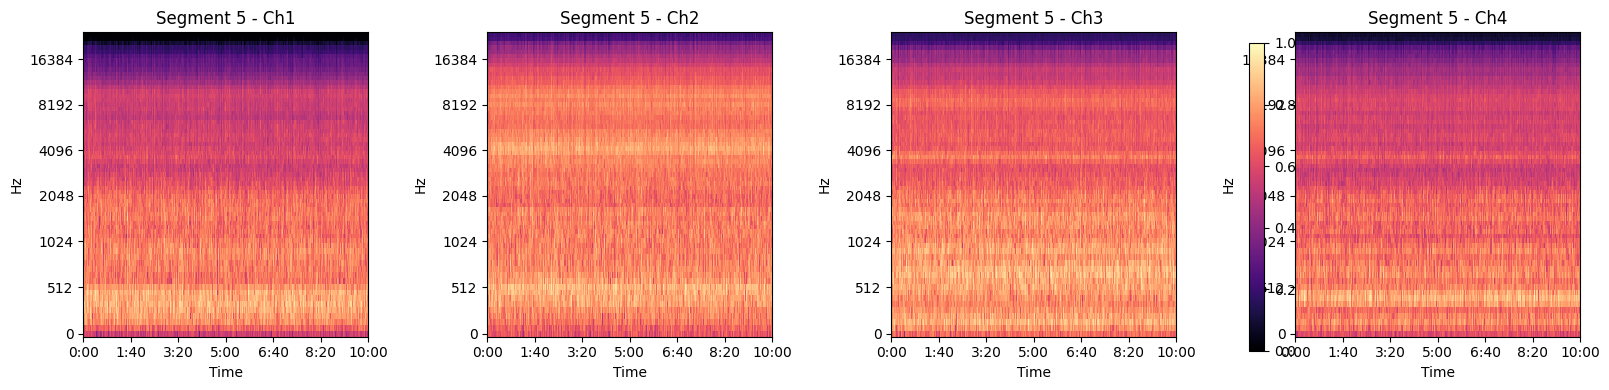

[SEGMENT 5] at 10200.42s


In [ ]:
# CNT silent segments are removed and the processed data is saved as .npy files in the save_path directory.
# The example shown is for Case 2, but the same procedure applies to other cases with appropriate configuration changes.

case = CASES[1]
cnt_base_path = f"{DATA_BASE_PATH}/{case}/NormalSound_CNT"
save_path = f"{DATA_BASE_PATH}/npy/CNT/{case}"

segment_sec = 10*60        # non-silent segment
skip_sec = 20*60           # silent segment
start_offset_sec = 1200    # start offset

channel_paths = {}

for ch in CHANNELS:
    pattern = f"1{case[-1]}001{ch}*_ToyCar_{case}_normal_CNT_ch{ch}_*.wav"
    channel_paths[ch] = sorted(glob.glob(os.path.join(cnt_base_path, pattern)))

extract_and_save_cnt_segments(
    channel_paths=channel_paths,
    save_path=save_path,
    segment_sec=segment_sec,
    skip_sec=skip_sec,     
    start_offset_sec=start_offset_sec,
    top_db=30,
    min_len_sec=500.0, 
    plot=True, 
    max_plots=5
)

After storing the full CNT spectrogram data as .npy files, it is further segmented into fixed-length windows matching the length of IND samples.

In [ ]:
# Split CNT spectrogram .npy files into fixed-length segments using sliding window (matching the length of IND spectrograms), 
# and save the resulting files to avoid repeated preprocessing.
split_cnt_to_segments_and_save(DATA_BASE_PATH, max_workers=8)